In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

filename = '../Data/genres_original/pop/pop.00000.wav'
y, sr = librosa.load(filename)
print(f"Sample rate: {sr}")

librosa.display.waveshow(y, sr=sr)

In [ ]:
# Phát âm thanh
from IPython.display import Audio
Audio(data=y, rate=sr)

In [ ]:
### Truc quan hoa cac doan am thanh
audio_path = '../Data/genres_original/pop/pop.00000.wav'
y, sr = librosa.load(filename,sr=None) #sr=None de giu nguyen sample rate goc cua file am thanh
# dinh nghia do dai cua khung va buoc nhay
chunk_duration=4  
overlap_duration=2

# chuyen doi duration sang so luong mau
chunk_samples=chunk_duration*sr
overlap_samples=overlap_duration*sr

# tinh toan so luong khung co the tao ra tu doan am thanh
num_chunks=int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1

# tao cac khung am thanh
for i in range(num_chunks):
    # start va end index cua khung
    start=i*(chunk_samples-overlap_samples)
    end=start+chunk_samples

    # cat khung am thanh
    chunk=y[start:end]
    plt.figure(figsize=(4,2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.tight_layout()
    plt.show()

In [ ]:
### Plotting MelSpectrogram Of Entire Audio
def plot_melspectrogram(y,sr):
    # Compute spectrogram
    spectrogram=librosa.feature.melspectrogram(y=y,sr=sr)
    # Convert to dB (log scale)
    spectrogram_db=librosa.power_to_db(spectrogram,ref=np.max)
    # Visualize the spectrogram
    plt.figure(figsize=(10,4))
    librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MelSpectrogram')
    plt.xlabel('Time')
    plt.ylabel('Mel Frequency')
    plt.show()


In [ ]:
filename = '../Data/genres_original/pop/pop.00000.wav'
y, sr = librosa.load(filename,sr=44100)
plot_melspectrogram(y,sr)

In [ ]:
def plot_melspectrogram_chunks(y,sr):
    # dinh nghia do dai cua khung va buoc nhay
    chunk_duration=4  
    overlap_duration=2

    # chuyen doi duration sang so luong mau
    chunk_samples=chunk_duration*sr
    overlap_samples=overlap_duration*sr

    # tinh toan so luong khung co the tao ra tu doan am thanh
    num_chunks=int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1

    # tao cac khung am thanh
    for i in range(num_chunks):
        # start va end index cua khung
        start=i*(chunk_samples-overlap_samples)
        end=start+chunk_samples

        # cat khung am thanh
        chunk=y[start:end]
        plot_melspectrogram(chunk,sr)
        

In [ ]:
filename = '../Data/genres_original/pop/pop.00000.wav'
y, sr = librosa.load(filename,sr=44100)
plot_melspectrogram_chunks(y,sr)

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("Đã bật Memory Growth cho GPU")
  except RuntimeError as e:
    print(e)

In [11]:
import os
import numpy as np
import librosa
from tensorflow.image import resize
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:


# DATA PREPROCESSING - FINAL
data_dir = "../Data/genres_original" 
classes = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

def load_and_preprocess_audio(data_dir, classes, target_shape=(150, 150)):
    data = []
    labels = []

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print(f"Đang xử lý thư mục: {class_name}...")
        
        for filename in os.listdir(class_dir):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir, filename)
             
                try:
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                except Exception as e:
                    print(f"  -> [Cảnh báo] Bỏ qua file lỗi: {filename} ({e})")
                    continue 
                # -------------------------------

                chunk_duration = 4
                overlap_duration = 2

                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                # Tính toán số lượng khung
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

                for i in range(num_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    # Đảm bảo chunk không vượt quá chiều dài của audio
                    chunk = audio_data[start:end]
                    
                    # Bỏ qua nếu chunk quá ngắn so với yêu cầu (thường ở cuối file)
                    if len(chunk) < chunk_samples:
                        continue

                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate)

                    # resize matrix mel spectrogram to 150x150
                    mel_spectrogram = resize(np.expand_dims(mel_spectrogram, axis=-1), target_shape)

                    # append mel spectrogram to data list and corresponding label to labels list
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    return np.array(data), np.array(labels)



In [3]:
# Chạy hàm tiền xử lý
data, labels = load_and_preprocess_audio(data_dir, classes)
print(f"\nHoàn tất! Tổng số mẫu data thu được: {data.shape}")
print(f"Tổng số nhãn labels thu được: {labels.shape}")

Đang xử lý thư mục: blues...
Đang xử lý thư mục: classical...
Đang xử lý thư mục: country...
Đang xử lý thư mục: disco...
Đang xử lý thư mục: hiphop...
Đang xử lý thư mục: jazz...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17872\3118616761.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sample_rate = librosa.load(file_path, sr=None)
d:\CondaEnvs\tensorflow_env\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  -> [Cảnh báo] Bỏ qua file lỗi: jazz.00054.wav ()
Đang xử lý thư mục: metal...
Đang xử lý thư mục: pop...
Đang xử lý thư mục: reggae...
Đang xử lý thư mục: rock...

Hoàn tất! Tổng số mẫu data thu được: (13977, 150, 150, 1)
Tổng số nhãn labels thu được: (13977,)


In [4]:
from tensorflow.keras.utils import to_categorical
labels_categorical = to_categorical(labels, num_classes=len(classes)) # Chuyển đổi nhãn sang one-hot encoding
print(f"Labels sau khi one-hot encoding: {labels_categorical}")
print(f"Shape của labels sau khi one-hot encoding: {labels_categorical.shape}")

Labels sau khi one-hot encoding: [[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
Shape của labels sau khi one-hot encoding: (13977, 10)


In [5]:
# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels_categorical, test_size=0.2, random_state=42)

In [ ]:
# Building model

In [8]:
import tensorflow


model=tensorflow.keras.Sequential()

In [9]:
X_train[0].shape

(150, 150, 1)

In [10]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=X_train[0].shape))
model.add(Conv2D(filters=32, kernel_size=3,  activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [11]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3,  activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [12]:
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3,  activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [13]:
model.add(Dropout(0.3))

In [14]:
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3,  activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [15]:
model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3,  activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [16]:
model.add(Dropout(0.3))

In [17]:
model.add(Flatten())

In [18]:
model.add(Dense(units=1200, activation='relu'))

In [19]:
model.add(Dropout(0.45))


In [20]:
# Output layer
model.add(Dense(units=len(classes), activation='softmax'))

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                    

In [22]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
# Training the model
training_history=model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
350/350 [==============================] - 50s 100ms/step - loss: 2.0096 - accuracy: 0.2477 - val_loss: 1.7288 - val_accuracy: 0.3373
Epoch 2/30
350/350 [==============================] - 30s 85ms/step - loss: 1.4499 - accuracy: 0.4821 - val_loss: 1.1855 - val_accuracy: 0.5798
Epoch 3/30
350/350 [==============================] - 30s 85ms/step - loss: 1.1342 - accuracy: 0.6062 - val_loss: 1.0094 - val_accuracy: 0.6599
Epoch 4/30
350/350 [==============================] - 30s 85ms/step - loss: 0.9455 - accuracy: 0.6732 - val_loss: 0.9011 - val_accuracy: 0.6849
Epoch 5/30
350/350 [==============================] - 30s 85ms/step - loss: 0.8052 - accuracy: 0.7250 - val_loss: 0.7804 - val_accuracy: 0.7364
Epoch 6/30
350/350 [==============================] - 30s 86ms/step - loss: 0.6795 - accuracy: 0.7700 - val_loss: 0.7227 - val_accuracy: 0.7579
Epoch 7/30
350/350 [==============================] - 30s 86ms/step - loss: 0.5882 - accuracy: 0.7981 - val_loss: 0.6023 - val_accuracy

In [24]:
model.save('music_genre_classification_model.h5')

In [25]:
# Recording training history in json file
import json
with open('training_history.json', 'w') as f:
    json.dump(training_history.history, f)

In [6]:
model=tf.keras.models.load_model('music_genre_classification_model.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                    

In [7]:
# Reading training history from json file
import json
with open('training_history.json', 'r') as json_file:
    training_history_data = json.load(json_file)

training_history_data.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [8]:
# Model evaluation on training set
val_loss, val_accuracy = model.evaluate(X_train, y_train)

350/350 [==============================] - 23s 28ms/step - loss: 0.0115 - accuracy: 0.9966


In [9]:
val_loss, val_accuracy

(0.011514098383486271, 0.996601402759552)

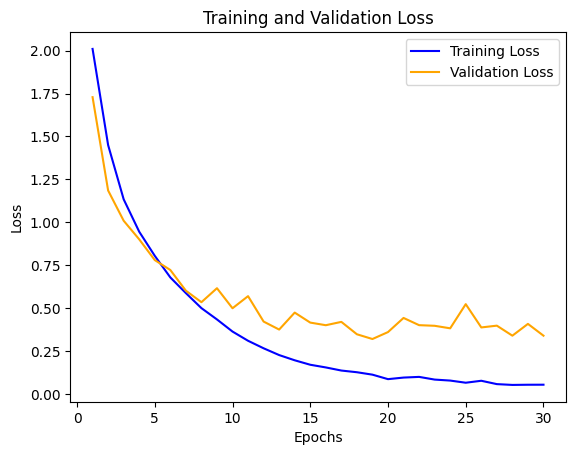

In [13]:
# Accuracy and loss visualization

# visualization training loss
epochs= [i for i in range(1,31)]
plt.plot(epochs, training_history_data['loss'], label='Training Loss',color='blue')
plt.plot(epochs, training_history_data['val_loss'], label='Validation Loss',color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



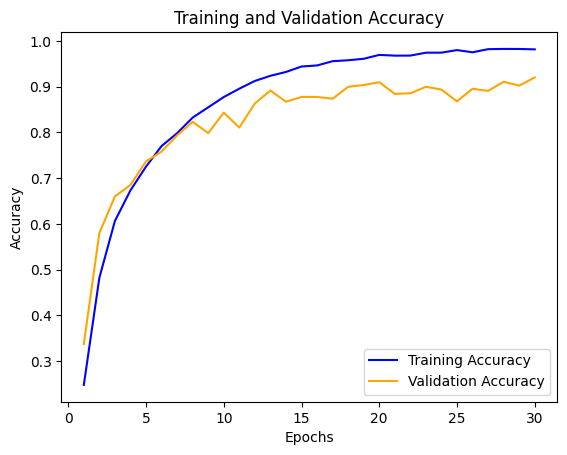

In [14]:
# Accuracy and loss visualization

# visualization training accuracy
epochs= [i for i in range(1,31)]
plt.plot(epochs, training_history_data['accuracy'], label='Training Accuracy',color='blue')
plt.plot(epochs, training_history_data['val_accuracy'], label='Validation Accuracy',color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

